# IkigoriSmart — Spread Risk Prediction Model
## Multimodal Decision Fusion: CNN Severity + Weather Data → Spread Risk

### Overview
This notebook builds the **second AI model** in the IkigoriSmart pipeline.
The first model (CNN) already predicts the **severity** of Maize Lethal 
Necrosis (MLN) from a leaf image. This notebook takes that severity output 
and combines it with **real-time weather variables** to predict the 
**speed and likelihood of disease spread** across neighboring maize fields.

### Why This Model is Necessary
Current AI tools for MLN detection treat disease as a **static condition** —
they only answer "is the plant infected?" They do not answer the farmer's 
most urgent question: *"Will this spread to my whole field by next week?"*

This model fills that gap by implementing what the literature calls 
**Multimodal Decision-Level Fusion** — combining visual intelligence 
(CNN severity) with environmental awareness (weather) to produce a 
**Spread Risk Score**: Low, Medium, or High.

> *"A significant challenge in MLN management is that symptoms like leaf 
> yellowing can easily be confused with nutrient deficiencies or heat stress. 
> Relying on images alone is insufficient."*
> — Prasanna (2021)

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

# Set random seed for reproducibility
# This means every time you run the code you get the same dataset
random.seed(42)
np.random.seed(42)

print("All libraries imported successfully")
print(f"Pandas version  : {pd.__version__}")
print(f"NumPy version   : {np.__version__}")

All libraries imported successfully
Pandas version  : 2.3.1
NumPy version   : 2.0.2


## Step 2 — The Rule-Based Scoring Function

### What is happening
This function is the **scientific heart** of the entire model. It takes 
4 inputs — severity, temperature, humidity, and rainfall — and assigns 
a **danger score** to each one based on verified biological thresholds 
from peer-reviewed literature. The total score determines the final 
Spread Risk label.

### Why a scoring function and not direct labeling
Instead of manually assigning labels, we use a **cumulative scoring 
approach**. This is important because MLN spread risk is not caused by 
one factor alone it is the **combination** of multiple stressors 
acting simultaneously. A plant with Moderate severity under perfect 
weather conditions may stay contained. The same plant under high 
temperature and drought stress will collapse rapidly.

This multi-factor scoring captures that biological reality.

### The Scoring Rules — All Literature-Grounded

| Variable | Condition | Score | Source |
|---|---|---|---|
| Severity | Severe | +3 | Mayo & Mduma (2024) |
| Severity | Moderate | +2 | Mayo & Mduma (2024) |
| Severity | Early | +1 | Mayo & Mduma (2024) |
| Temperature | 25°C–30°C | +2 | CIMMYT (2021) |
| Temperature | >30°C | +1 | CIMMYT (2021) |
| Temperature | 22°C–25°C | +1 | Ngarukiyimana et al. (2021) |
| Humidity | >80% | +2 | Prasanna (2021) |
| Humidity | 60%–80% | +1 | Prasanna (2021) |
| Rainfall | <20mm | +2 | Prasanna (2021) |
| Rainfall | 20mm–50mm | +1 | Prasanna (2021) |

### Maximum Possible Score
3 (severity) + 2 (temperature) + 2 (humidity) + 2 (rainfall) = **9**

### Final Label Thresholds
- Score ≥ 7 → **High Risk** — multiple danger conditions simultaneously
- Score 4–6 → **Medium Risk** — some risk factors present
- Score 0–3 → **Low Risk** — conditions relatively safe

### References
- CIMMYT. (2021). *MLN Disease Management Technical Manual.* 
  https://mln.cimmyt.org/wp-content/uploads/sites/39/2021/10/MLN-Disease-Management_Technical-Manual-CIMMYT.pdf
- Prasanna, B. M. (2021). *Maize Lethal Necrosis: A Technical Manual.* CIMMYT.
- Mayo, P., & Mduma, N. (2024). *CNN for Early Detection of MLN.* 
  East African Journal of Science, Technology and Innovation.
- Ngarukiyimana, J. P., et al. (2021). *Climate Change in Rwanda.* 
  Frontiers in Earth Science, 9, 619512. 
  https://doi.org/10.3389/feart.2021.619512

In [2]:
def assign_risk_label(severity, temperature, humidity, rainfall):
    """
    Rule-based risk labeling function.
    
    Rules derived from peer-reviewed literature:
    - Temperature thresholds : CIMMYT (2021)
    - Humidity thresholds    : Prasanna (2021)
    - Rainfall thresholds    : Prasanna (2021)
    - Severity levels        : Mayo & Mduma (2024)
    
    Parameters:
        severity    : str   — CNN output (Healthy/Early/Moderate/Severe)
        temperature : float — Temperature in Celsius
        humidity    : float — Relative humidity in percentage
        rainfall    : float — Rainfall in mm
    
    Returns:
        str — Risk label (Low / Medium / High)
    """
    
    score = 0
    
    # ── Severity Score ─────────────────────────────────────────────
    # Source: Mayo & Mduma (2024)
    # The CNN output directly determines base danger level
    if severity == 'Severe':
        score += 3   # Already catastrophic — maximum base score
    elif severity == 'Moderate':
        score += 2   # Significant infection — high base concern
    elif severity == 'Early':
        score += 1   # Initial symptoms — low but real concern
    else:            # Healthy
        score += 0   # No infection detected — zero base score
    
    # ── Temperature Score ──────────────────────────────────────────
    # Optimal insect vector breeding zone: 25°C–30°C
    # Thrips and aphids reproduce fastest in this range
    # Source: CIMMYT (2021)
    if 25 <= temperature <= 30:
        score += 2   # Perfect breeding zone for thrips and aphids
    elif temperature > 30:
        score += 1   # Too hot — vectors slow down slightly
    elif 22 <= temperature < 25:
        score += 1   # Approaching danger zone — moderate concern
    else:
        score += 0   # Below 22°C — vectors largely inactive
    
    # ── Humidity Score ─────────────────────────────────────────────
    # Above 80% is ideal for insect activity and virus stability
    # Source: Prasanna (2021)
    if humidity > 80:
        score += 2   # Danger zone — insects thrive, virus survives longer
    elif humidity >= 60:
        score += 1   # Moderate concern — conditions becoming favorable
    else:
        score += 0   # Below 60% — less favorable for spread
    
    # ── Rainfall / Drought Score ───────────────────────────────────
    # Low rainfall = drought stress = weakened plant immunity
    # Counterintuitive: LESS rain = MORE risk
    # Source: Prasanna (2021)
    if rainfall < 20:
        score += 2   # Severe drought stress — plant immunity collapsed
    elif rainfall < 50:
        score += 1   # Moderate dryness — plant slightly stressed
    else:
        score += 0   # Sufficient rainfall — plant resilient
    
    # ── Final Verdict ──────────────────────────────────────────────
    # Maximum possible score = 3 + 2 + 2 + 2 = 9
    if score >= 7:
        return 'High'
    elif score >= 4:
        return 'Medium'
    else:
        return 'Low'

print("Scoring function defined successfully")

# Quick test to verify the function works correctly
test_cases = [
    ('Severe',  28.0, 88.0,  10.0, 'Expected: High'),
    ('Healthy', 20.0, 65.0, 120.0, 'Expected: Low'),
    ('Moderate',22.0, 75.0,  45.0, 'Expected: Medium'),
]

print("\nFunction verification tests:")
print("-" * 50)
for sev, temp, hum, rain, expected in test_cases:
    result = assign_risk_label(sev, temp, hum, rain)
    print(f"Severity={sev:8} | Temp={temp} | "
          f"Hum={hum} | Rain={rain} "
          f"→ {result:6} | {expected}")

Scoring function defined successfully

Function verification tests:
--------------------------------------------------
Severity=Severe   | Temp=28.0 | Hum=88.0 | Rain=10.0 → High   | Expected: High
Severity=Healthy  | Temp=20.0 | Hum=65.0 | Rain=120.0 → Low    | Expected: Low
Severity=Moderate | Temp=22.0 | Hum=75.0 | Rain=45.0 → Medium | Expected: Medium


## Step 3 — Synthetic Dataset Generation

### What is happening
We generate **2000 synthetic data rows** representing imaginary farmer 
scan scenarios. Each row contains a severity level, three weather 
variables, a district, and the spread risk label calculated by our 
scoring function.

### Why Synthetic Data is Valid for This Research
No real-world labeled dataset exists that combines MLN severity scores 
with Rwandan weather conditions and human-verified spread risk labels. 
Collecting such data would require years of field surveys across 
Musanze and Nyabihu.

**Rule-Based Synthetic Data Generation** is an established and 
defensible methodology in agricultural AI research when:
1. The labeling rules are derived from peer-reviewed literature 
2. The input ranges reflect verified real-world measurements 
3. The methodology is transparently documented 

This approach is validated by Sibiya (2021) and supported by the 
broader practice of simulation-based dataset generation in precision 
agriculture research.

### The Two-Population Strategy

We generate data from **two distinct climate populations**:

**Population 1 — Current Rwanda Climate (60% = 1200 rows)**
Reflects today's verified Musanze/Nyabihu conditions.
- Temperature: **19°C–24°C**
  Source: Ngarukiyimana et al. (2021) — verified highland range
- Humidity: **60%–85%**
  Source: Twahirwa et al. (2023) — verified Musanze range
- Rainfall: **15mm–180mm**
  Source: Twahirwa et al. (2023) — July minimum to April peak

**Population 2 — Stress Scenario Climate (40% = 800 rows)**
Reflects projected extreme conditions touching CIMMYT thresholds.
Rwanda is warming at **0.17–0.20°C per decade** — these conditions 
are scientifically projected for this region within 15–25 years.
- Temperature: **23°C–30°C**
  Source: CIMMYT (2021) danger zone + Ngarukiyimana et al. (2021) projection
- Humidity: **75%–95%**
  Source: Prasanna (2021) — touching/above 80% danger threshold
- Rainfall: **5mm–30mm**
  Source: Prasanna (2021) — touching/below 20mm drought threshold

### Why Include Stress Scenarios
Including only current climate data would make the model blind to 
dangerous threshold conditions  defeating the purpose of building 
an early warning system. The PSTA 5 (MINAGRI, 2024) explicitly 
identifies climate stress as a key future risk for Rwandan agriculture. 
This model must be ready for those conditions now.

### The `scenario` Column
We add a `scenario` column to track which population each row came from. 
This column is **used only for analysis** — it is dropped before model 
training so the model learns only from actual agricultural features.

### References
- Ngarukiyimana, J. P., et al. (2021). *Climate Change in Rwanda.*
  Frontiers in Earth Science. https://doi.org/10.3389/feart.2021.619512
- Twahirwa, A., et al. (2023). *Variability and Trends of Rainfall 
  and Temperature for Musanze District.* 
  https://onlinelibrary.wiley.com/doi/10.1155/2023/7177776
- MINAGRI. (2024). *PSTA 5 — Building Resilient Agri-Food Systems.*
- Sibiya, M. (2021). *Deep Learning for Maize Disease Severity.*
  University of South Africa. https://hdl.handle.net/10500/28483
- CIMMYT. (2021). *MLN Disease Management Technical Manual.*

In [3]:
# ── Configuration ─────────────────────────────────────────────────
TOTAL_ROWS = 2000
POP1_SIZE  = int(TOTAL_ROWS * 0.60)  # 1200 rows — current Rwanda climate
POP2_SIZE  = int(TOTAL_ROWS * 0.40)  # 800 rows  — stress scenario

severities = ['Healthy', 'Early', 'Moderate', 'Severe']
districts  = ['Musanze', 'Nyabihu']

rows = []

# ── Population 1 — Current Rwanda Climate (60%) ───────────────────
# Source: Ngarukiyimana et al. (2021), Twahirwa et al. (2023)

print("Generating Population 1 — Current Rwanda Climate...")

for _ in range(POP1_SIZE):
    severity = random.choice(severities)
    district = random.choice(districts)
    
    # Verified Rwanda highland ranges
    # Source: Ngarukiyimana et al. (2021), Twahirwa et al. (2023)
    temperature = round(random.uniform(19, 24), 1)
    humidity    = round(random.uniform(60, 85), 1)
    rainfall    = round(random.uniform(15, 180), 1)
    
    label = assign_risk_label(severity, temperature, humidity, rainfall)
    
    rows.append({
        'severity'      : severity,
        'temperature_c' : temperature,
        'humidity_pct'  : humidity,
        'rainfall_mm'   : rainfall,
        'district'      : district,
        'scenario'      : 'current',
        'spread_risk'   : label
    })

print(f"✓ Population 1 complete: {POP1_SIZE} rows")

# ── Population 2 — Stress Scenario Climate (40%) ──────────────────
# Source: CIMMYT (2021), Prasanna (2021), Ngarukiyimana et al. (2021)

print("Generating Population 2 — Stress Scenario Climate...")

for _ in range(POP2_SIZE):
    severity = random.choice(severities)
    district = random.choice(districts)
    
    # Stress scenario — touching CIMMYT biological thresholds
    # Source: CIMMYT (2021), Prasanna (2021)
    temperature = round(random.uniform(23, 30), 1)
    humidity    = round(random.uniform(75, 95), 1)
    rainfall    = round(random.uniform(5,  30), 1)
    
    label = assign_risk_label(severity, temperature, humidity, rainfall)
    
    rows.append({
        'severity'      : severity,
        'temperature_c' : temperature,
        'humidity_pct'  : humidity,
        'rainfall_mm'   : rainfall,
        'district'      : district,
        'scenario'      : 'stress',
        'spread_risk'   : label
    })

print(f"✓ Population 2 complete: {POP2_SIZE} rows")

# ── Build and Shuffle DataFrame ────────────────────────────────────
df = pd.DataFrame(rows)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✓ Total dataset: {len(df)} rows")
print("\nDataset preview (first 10 rows):")
df.head(10)

Generating Population 1 — Current Rwanda Climate...
✓ Population 1 complete: 1200 rows
Generating Population 2 — Stress Scenario Climate...
✓ Population 2 complete: 800 rows

✓ Total dataset: 2000 rows

Dataset preview (first 10 rows):


,severity,temperature_c,humidity_pct,rainfall_mm,district,scenario,spread_risk
0,Moderate,29.3,75.6,8.5,Musanze,stress,High
1,Moderate,20.7,71.1,57.3,Musanze,current,Low
2,Healthy,26.6,83.3,16.6,Musanze,stress,Medium
3,Moderate,22.5,70.7,32.2,Nyabihu,current,Medium
4,Early,25.8,83.6,11.5,Musanze,stress,High
5,Early,26.9,81.2,29.0,Nyabihu,stress,Medium
6,Healthy,22.3,60.2,79.1,Nyabihu,current,Low
7,Moderate,24.9,90.8,21.1,Musanze,stress,Medium
8,Severe,20.3,79.7,32.8,Musanze,current,Medium
9,Healthy,24.1,90.6,12.1,Musanze,stress,Medium


DATASET STATISTICS

1. Spread Risk Distribution (Target Variable):
spread_risk
Medium    939
Low       649
High      412
Name: count, dtype: int64

As percentages:
spread_risk
Medium    46.9
Low       32.4
High      20.6
Name: proportion, dtype: float64

2. Severity Distribution:
severity
Severe      533
Early       494
Moderate    488
Healthy     485
Name: count, dtype: int64

3. Scenario Distribution:
scenario
current    1200
stress      800
Name: count, dtype: int64

4. Weather Variable Summary Statistics:
       temperature_c  humidity_pct  rainfall_mm
count        2000.00       2000.00      2000.00
mean           23.45         77.32        65.94
std             2.93          9.12        54.18
min            19.00         60.00         5.00
25%            21.10         70.10        19.70
50%            23.10         77.60        42.60
75%            25.40         83.90       112.02
max            30.00         95.00       180.00


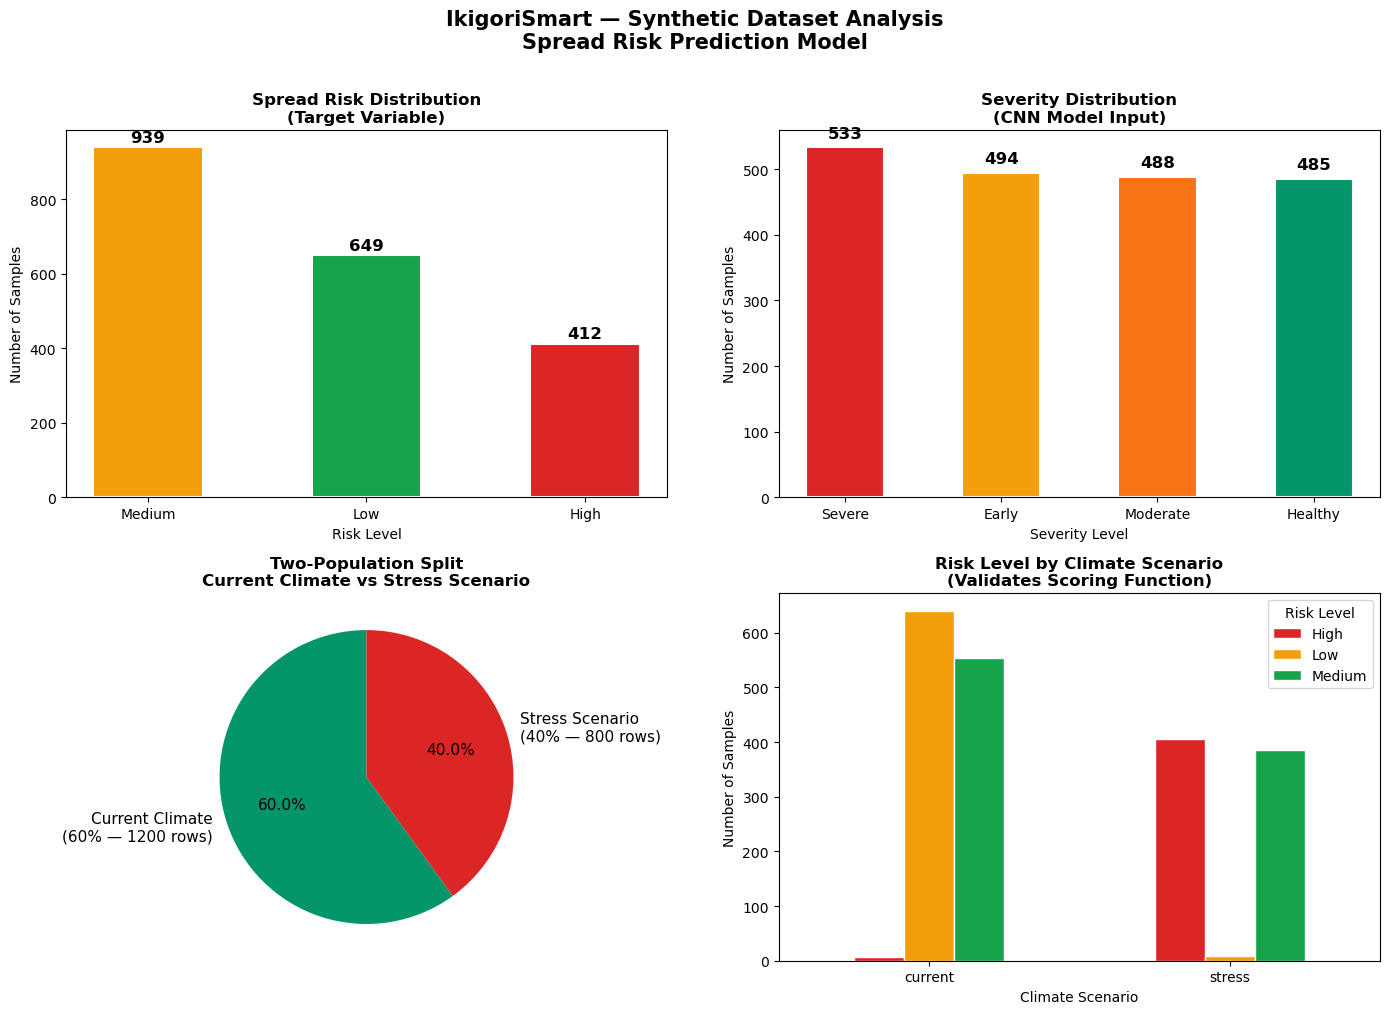

✓ Chart saved as dataset_analysis.png


In [4]:
print("=" * 55)
print("DATASET STATISTICS")
print("=" * 55)

print("\n1. Spread Risk Distribution (Target Variable):")
risk_counts = df['spread_risk'].value_counts()
print(risk_counts)
print("\nAs percentages:")
print((df['spread_risk'].value_counts(normalize=True) * 100).round(1))

print("\n2. Severity Distribution:")
print(df['severity'].value_counts())

print("\n3. Scenario Distribution:")
print(df['scenario'].value_counts())

print("\n4. Weather Variable Summary Statistics:")
print(df[['temperature_c','humidity_pct','rainfall_mm']].describe().round(2))

# ── Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'IkigoriSmart — Synthetic Dataset Analysis\n'
    'Spread Risk Prediction Model',
    fontsize=15, fontweight='bold', y=1.01
)

# Chart 1 — Risk Label Distribution
colors_risk = {
    'Low'   : '#16a34a',
    'Medium': '#f59e0b',
    'High'  : '#dc2626'
}
risk_counts = df['spread_risk'].value_counts()
bars = axes[0,0].bar(
    risk_counts.index,
    risk_counts.values,
    color=[colors_risk[r] for r in risk_counts.index],
    edgecolor='white', linewidth=1.5, width=0.5
)
axes[0,0].set_title('Spread Risk Distribution\n(Target Variable)',
                     fontweight='bold')
axes[0,0].set_xlabel('Risk Level')
axes[0,0].set_ylabel('Number of Samples')
for bar, val in zip(bars, risk_counts.values):
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 15,
        str(val), ha='center', fontweight='bold', fontsize=12
    )

# Chart 2 — Severity Distribution
colors_sev = {
    'Healthy' : '#04966a',
    'Early'   : '#f59e0b',
    'Moderate': '#f97316',
    'Severe'  : '#dc2626'
}
sev_counts = df['severity'].value_counts()
bars2 = axes[0,1].bar(
    sev_counts.index,
    sev_counts.values,
    color=[colors_sev[s] for s in sev_counts.index],
    edgecolor='white', linewidth=1.5, width=0.5
)
axes[0,1].set_title('Severity Distribution\n(CNN Model Input)',
                      fontweight='bold')
axes[0,1].set_xlabel('Severity Level')
axes[0,1].set_ylabel('Number of Samples')
for bar, val in zip(bars2, sev_counts.values):
    axes[0,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 15,
        str(val), ha='center', fontweight='bold', fontsize=12
    )

# Chart 3 — Population Split Pie
scenario_counts = df['scenario'].value_counts()
axes[1,0].pie(
    scenario_counts.values,
    labels=[
        f'Current Climate\n(60% — {scenario_counts["current"]} rows)',
        f'Stress Scenario\n(40% — {scenario_counts["stress"]} rows)'
    ],
    colors=['#04966a', '#dc2626'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1,0].set_title(
    'Two-Population Split\nCurrent Climate vs Stress Scenario',
    fontweight='bold'
)

# Chart 4 — Risk Level by Scenario
risk_by_scenario = df.groupby(
    ['scenario', 'spread_risk']
).size().unstack(fill_value=0)

risk_by_scenario.plot(
    kind='bar',
    ax=axes[1,1],
    color=['#dc2626', '#f59e0b', '#16a34a'],
    edgecolor='white',
    width=0.5
)
axes[1,1].set_title(
    'Risk Level by Climate Scenario\n(Validates Scoring Function)',
    fontweight='bold'
)
axes[1,1].set_xlabel('Climate Scenario')
axes[1,1].set_ylabel('Number of Samples')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='Risk Level', loc='upper right')

plt.tight_layout()
plt.savefig('dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved as dataset_analysis.png")

In [5]:
# ── Drop scenario column — analysis only, not a model feature ──────
df_model = df.drop(columns=['scenario'])

# ── Initialize Label Encoders ──────────────────────────────────────
le_severity = LabelEncoder()
le_district = LabelEncoder()
le_risk     = LabelEncoder()

# ── Fit and Transform ──────────────────────────────────────────────
df_model['severity_enc'] = le_severity.fit_transform(df_model['severity'])
df_model['district_enc'] = le_district.fit_transform(df_model['district'])
df_model['risk_enc']     = le_risk.fit_transform(df_model['spread_risk'])

print("Label Encoding Results:")
print("-" * 40)
print("Severity encoding:")
for i, cls in enumerate(le_severity.classes_):
    print(f"  {cls:10} → {i}")

print("\nDistrict encoding:")
for i, cls in enumerate(le_district.classes_):
    print(f"  {cls:10} → {i}")

print("\nRisk encoding (Target):")
for i, cls in enumerate(le_risk.classes_):
    print(f"  {cls:10} → {i}")

# ── Define Features and Target ─────────────────────────────────────
X = df_model[[
    'severity_enc',
    'temperature_c',
    'humidity_pct',
    'rainfall_mm',
    'district_enc'
]]

y = df_model['risk_enc']

print(f"\n✓ Features matrix shape : {X.shape}")
print(f"✓ Target vector shape   : {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Label Encoding Results:
----------------------------------------
Severity encoding:
  Early      → 0
  Healthy    → 1
  Moderate   → 2
  Severe     → 3

District encoding:
  Musanze    → 0
  Nyabihu    → 1

Risk encoding (Target):
  High       → 0
  Low        → 1
  Medium     → 2

✓ Features matrix shape : (2000, 5)
✓ Target vector shape   : (2000,)

Feature columns: ['severity_enc', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'district_enc']


In [6]:
# ── Train/Test Split ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # Equal risk class proportions in both sets
)

print("Train/Test Split Results:")
print("-" * 40)
print(f"Total samples    : {len(X)}")
print(f"Training samples : {len(X_train)} (80%)")
print(f"Testing samples  : {len(X_test)} (20%)")

print("\nRisk class distribution in training set:")
train_dist = pd.Series(
    le_risk.inverse_transform(y_train)
).value_counts()
print(train_dist)

print("\nRisk class distribution in testing set:")
test_dist = pd.Series(
    le_risk.inverse_transform(y_test)
).value_counts()
print(test_dist)

Train/Test Split Results:
----------------------------------------
Total samples    : 2000
Training samples : 1600 (80%)
Testing samples  : 400 (20%)

Risk class distribution in training set:
Medium    751
Low       519
High      330
Name: count, dtype: int64

Risk class distribution in testing set:
Medium    188
Low       130
High       82
Name: count, dtype: int64


In [7]:
print("Training Random Forest Classifier...")
print("-" * 40)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

print("✓ Training complete!")
print(f"  Number of trees     : {model.n_estimators}")
print(f"  Number of features  : {model.n_features_in_}")
print(f"  Feature names       : {list(X.columns)}")

Training Random Forest Classifier...
----------------------------------------
✓ Training complete!
  Number of trees     : 100
  Number of features  : 5
  Feature names       : ['severity_enc', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'district_enc']


MODEL EVALUATION REPORT
              precision    recall  f1-score   support

        High       1.00      0.95      0.97        82
         Low       0.99      0.98      0.99       130
      Medium       0.97      0.99      0.98       188

    accuracy                           0.98       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400

Overall Accuracy: 98.25%


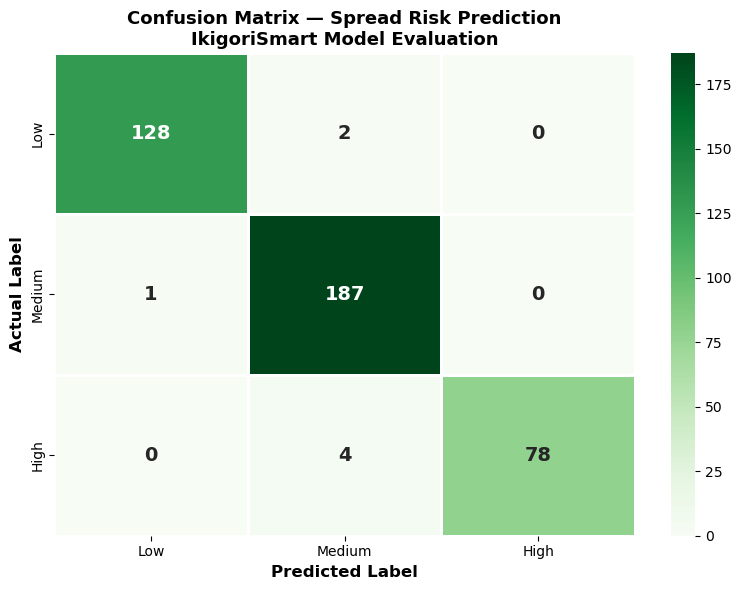

✓ Confusion matrix saved as confusion_matrix.png


In [8]:
# ── Predictions on Test Set ────────────────────────────────────────
y_pred = model.predict(X_test)

# Decode back to readable labels
y_test_labels = le_risk.inverse_transform(y_test)
y_pred_labels = le_risk.inverse_transform(y_pred)

# ── Classification Report ──────────────────────────────────────────
print("=" * 55)
print("MODEL EVALUATION REPORT")
print("=" * 55)
print(classification_report(y_test_labels, y_pred_labels))

overall_accuracy = model.score(X_test, y_test)
print(f"Overall Accuracy: {overall_accuracy * 100:.2f}%")

# ── Confusion Matrix ───────────────────────────────────────────────
cm = confusion_matrix(
    y_test_labels,
    y_pred_labels,
    labels=['Low', 'Medium', 'High']
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High'],
    linewidths=2,
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title(
    'Confusion Matrix — Spread Risk Prediction\n'
    'IkigoriSmart Model Evaluation',
    fontweight='bold', fontsize=13
)
plt.ylabel('Actual Label', fontweight='bold', fontsize=12)
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Confusion matrix saved as confusion_matrix.png")

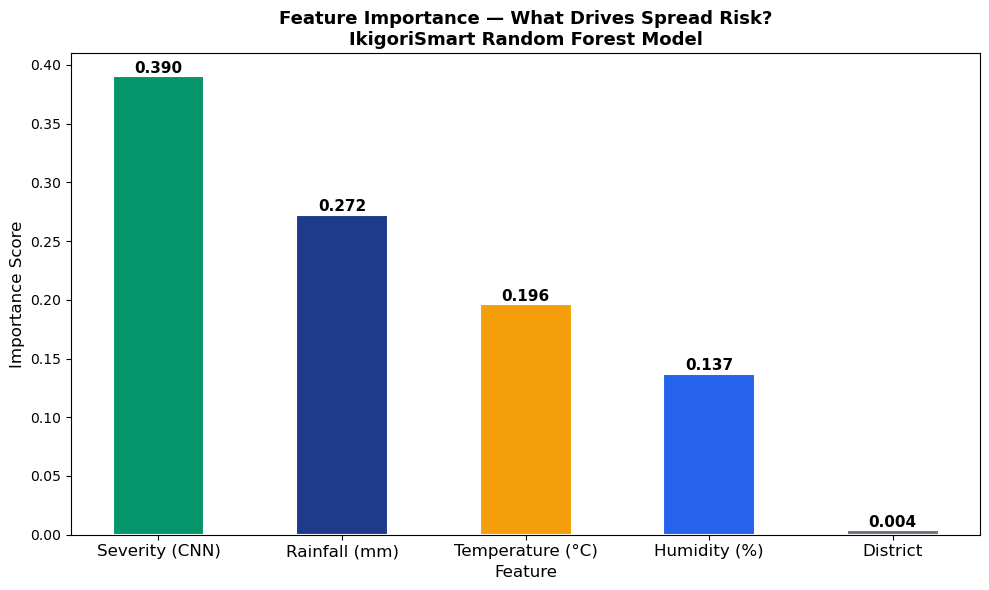

✓ Feature importance chart saved as feature_importance.png

Feature Importance Ranking:
----------------------------------------
  Severity (CNN)       : 0.3904  ███████████████████████████████████████
  Rainfall (mm)        : 0.2724  ███████████████████████████
  Temperature (°C)     : 0.1963  ███████████████████
  Humidity (%)         : 0.1371  █████████████
  District             : 0.0038  


In [9]:
feature_names = [
    'Severity (CNN)',
    'Temperature (°C)',
    'Humidity (%)',
    'Rainfall (mm)',
    'District'
]

importances = model.feature_importances_
indices     = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in indices]
sorted_imps  = importances[indices]

colors_feat = ['#04966a','#1e3a8a','#f59e0b','#2563eb','#6b7280']

plt.figure(figsize=(10, 6))
bars = plt.bar(
    range(len(feature_names)),
    sorted_imps,
    color=colors_feat,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
plt.xticks(range(len(feature_names)), sorted_names, fontsize=12)
plt.title(
    'Feature Importance — What Drives Spread Risk?\n'
    'IkigoriSmart Random Forest Model',
    fontweight='bold', fontsize=13
)
plt.ylabel('Importance Score', fontsize=12)
plt.xlabel('Feature', fontsize=12)

for bar, imp in zip(bars, sorted_imps):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f'{imp:.3f}',
        ha='center', fontweight='bold', fontsize=11
    )

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Feature importance chart saved as feature_importance.png")
print("\nFeature Importance Ranking:")
print("-" * 40)
for name, imp in zip(sorted_names, sorted_imps):
    bar = '█' * int(imp * 100)
    print(f"  {name:20} : {imp:.4f}  {bar}")

In [10]:
# ── Save Model and Encoders ────────────────────────────────────────
joblib.dump(model,       'spread_risk_model.pkl')
joblib.dump(le_severity, 'encoder_severity.pkl')
joblib.dump(le_district, 'encoder_district.pkl')
joblib.dump(le_risk,     'encoder_risk.pkl')

# Save dataset
df.to_csv('spread_risk_dataset.csv', index=False)

print("✓ All files saved successfully:")
print("  spread_risk_model.pkl    — Trained Random Forest model")
print("  encoder_severity.pkl     — Severity label encoder")
print("  encoder_district.pkl     — District label encoder")
print("  encoder_risk.pkl         — Risk label encoder")
print("  spread_risk_dataset.csv  — Full synthetic dataset (2000 rows)")

import os
for fname in ['spread_risk_model.pkl', 'encoder_severity.pkl',
              'encoder_district.pkl', 'encoder_risk.pkl',
              'spread_risk_dataset.csv']:
    size = os.path.getsize(fname)
    print(f"  {fname:35} {size:>8} bytes")

✓ All files saved successfully:
  spread_risk_model.pkl    — Trained Random Forest model
  encoder_severity.pkl     — Severity label encoder
  encoder_district.pkl     — District label encoder
  encoder_risk.pkl         — Risk label encoder
  spread_risk_dataset.csv  — Full synthetic dataset (2000 rows)
  spread_risk_model.pkl                1477345 bytes
  encoder_severity.pkl                     511 bytes
  encoder_district.pkl                     493 bytes
  encoder_risk.pkl                         495 bytes
  spread_risk_dataset.csv                87897 bytes
